In [23]:
from scipy.stats import mannwhitneyu
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("data")  
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)



In [15]:
df = pd.read_csv(DATA_DIR / "anonymized_data.csv")

In [70]:
# ---- settings ----
iterations = 1000 
TONE_COLS = ['Appreciation', 'Constructiveness', 'Clarifications', 'Critique']
CONFOUNDERS = {
    'gender':   ['Male', 'Female'],
    'race':     ['White', 'NonWhite'],
    'region':   ['Western', 'Eastern'],
    'uni_rank': ['Top100', 'Other'],
}

def calculate_rbc(u_stat: float, n1: int, n2: int) -> float:
    # Rank-biserial correlation from Mann–Whitney U
    return (2 * u_stat) / (n1 * n2) - 1

def bootstrap_rbc(group1: np.ndarray,
                  group2: np.ndarray,
                  n_iter: int = iterations,
                  seed: int = 42) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return (np.nan, np.nan)

    rbcs = []
    for _ in range(n_iter):
        s1 = rng.choice(group1, size=n1, replace=True)
        s2 = rng.choice(group2, size=n2, replace=True)
        try:
            u, _ = mannwhitneyu(s1, s2, alternative='two-sided')
            rbcs.append(calculate_rbc(u, n1, n2))
        except ValueError:
            pass

    if len(rbcs) >= max(30, n_iter // 10):
        lo, hi = np.percentile(rbcs, [2.5, 97.5])
        return (float(lo), float(hi))
    return (np.nan, np.nan)

def p_to_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def _subset_for_identity(df, identity_label: str):
    """Return the slice of df to analyze for the given identity."""
    base = df[df['word_count'] > 5]
    if identity_label == 'Disclosed':
        return base[base['disclosed_reviewer'] == 1]
    if identity_label == 'Undisclosed':
        return base[base['disclosed_reviewer'] == 0]
    #identity_label == 'All' → full dataset 
    return base

def run_hypothesis_tests(df: pd.DataFrame,
                         tone_cols=TONE_COLS,
                         confounders=CONFOUNDERS,
                         n_boot: int = iterations,
                         seed: int = 42) -> pd.DataFrame:
    # ensure numeric
    for c in tone_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    out = []
    for identity_label in ['Disclosed', 'Undisclosed', 'All']:
        subset = _subset_for_identity(df, identity_label)

        for conf_name, (g1, g2) in confounders.items():
            s1 = subset[subset[conf_name] == g1]
            s2 = subset[subset[conf_name] == g2]

            for tone in tone_cols:
                v1 = s1[tone].dropna().values
                v2 = s2[tone].dropna().values
                n1, n2 = len(v1), len(v2)

                u = p = rbc = ci_lo = ci_hi = np.nan
                if n1 > 1 and n2 > 1:
                    try:
                        u, p = mannwhitneyu(v1, v2, alternative='two-sided')
                        rbc = calculate_rbc(u, n1, n2)
                        ci_lo, ci_hi = bootstrap_rbc(v1, v2, n_iter=n_boot, seed=seed)
                    except ValueError:
                        pass

                mean1 = np.mean(v1) if n1 else np.nan
                mean2 = np.mean(v2) if n2 else np.nan
                se1   = (np.std(v1, ddof=1) / np.sqrt(n1)) if n1 > 1 else np.nan
                se2   = (np.std(v2, ddof=1) / np.sqrt(n2)) if n2 > 1 else np.nan
                higher = '' if (pd.isna(mean1) or pd.isna(mean2)) else (g1 if mean1 > mean2 else g2 if mean2 > mean1 else 'Equal')

                out.append({
                    'Tone Category': tone,
                    'Reviewer Identity': identity_label,
                    'Confounder': conf_name,
                    'Group 1': g1, 'Group 2': g2,
                    'Group 1 Mean': mean1, 'Group 2 Mean': mean2,
                    'Group 1 Size': n1, 'Group 2 Size': n2,
                    'Group 1 SE': se1, 'Group 2 SE': se2,
                    'U-statistic': u, 'P-value': p,
                    'Effect Size (RBC)': rbc,
                    'Effect Size CI Lower': ci_lo,
                    'Effect Size CI Upper': ci_hi,
                    'Significance': p_to_stars(p),
                    'Higher Group': higher,
                })

    res = pd.DataFrame(out)
    cols = ['Tone Category','Reviewer Identity','Confounder','Group 1','Group 2',
            'Group 1 Mean','Group 1 SE','Group 1 Size',
            'Group 2 Mean','Group 2 SE','Group 2 Size',
            'U-statistic','P-value','Significance',
            'Effect Size (RBC)','Effect Size CI Lower','Effect Size CI Upper',
            'Higher Group']
    return res[cols]




In [71]:
# ---- run & save ----
results_ttest = run_hypothesis_tests(df, n_boot=iterations, seed=42)
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
out_csv = RESULTS_DIR / "mannwhitney_rbc_results.csv"
results_ttest.to_csv(out_csv, index=False)
results_ttest.to_parquet(RESULTS_DIR / "mannwhitney_rbc_results.parquet", index=False)
print(f"Saved: {out_csv.resolve()}")

Saved: C:\Users\ms13502\peer_review_project\results\mannwhitney_rbc_results.csv


In [72]:
results_ttest

,Tone Category,Reviewer Identity,Confounder,Group 1,Group 2,Group 1 Mean,Group 1 SE,Group 1 Size,Group 2 Mean,Group 2 SE,Group 2 Size,U-statistic,P-value,Significance,Effect Size (RBC),Effect Size CI Lower,Effect Size CI Upper,Higher Group
0,Appreciation,Disclosed,gender,Male,Female,3.205395,0.083552,10520,3.698048,0.131461,5848,29860306.0,1.275553e-04,***,-0.029264,NaN,NaN,Female
1,Constructiveness,Disclosed,gender,Male,Female,2.864978,0.060870,10520,2.833130,0.081434,5848,30869377.0,6.541468e-01,,0.003540,NaN,NaN,Male
2,Clarifications,Disclosed,gender,Male,Female,3.315012,0.059077,10520,3.307963,0.078389,5848,30767678.0,9.776082e-01,,0.000234,NaN,NaN,Male
3,Critique,Disclosed,gender,Male,Female,1.589307,0.040726,10520,1.633452,0.059978,5848,30792692.0,8.827440e-01,,0.001047,NaN,NaN,Female
4,Appreciation,Disclosed,race,White,NonWhite,3.585966,0.115283,6474,3.247563,0.090798,9894,33985784.0,3.068779e-16,***,0.061164,NaN,NaN,White
5,Constructiveness,Disclosed,race,White,NonWhite,2.695503,0.072815,6474,2.957048,0.065060,9894,32016156.0,9.655196e-01,,-0.000335,NaN,NaN,NonWhite
6,Clarifications,Disclosed,race,White,NonWhite,3.170904,0.071674,6474,3.405141,0.062375,9894,32059687.5,9.002165e-01,,0.001024,NaN,NaN,NonWhite
7,Critique,Disclosed,race,White,NonWhite,1.502051,0.049390,6474,1.672494,0.045677,9894,32165344.0,5.343684e-01,,0.004323,NaN,NaN,NonWhite
8,Appreciation,Disclosed,region,Western,Eastern,3.450891,0.096295,9224,3.293878,0.106287,7137,35285326.0,1.819157e-22,***,0.071986,NaN,NaN,Western
9,Constructiveness,Disclosed,region,Western,Eastern,2.682330,0.060830,9224,3.076262,0.079427,7137,33069748.5,5.403748e-01,,0.004676,NaN,NaN,Eastern


Saved figure → C:\Users\ms13502\peer_review_project\figures\mannwhitney_12subplots.svg


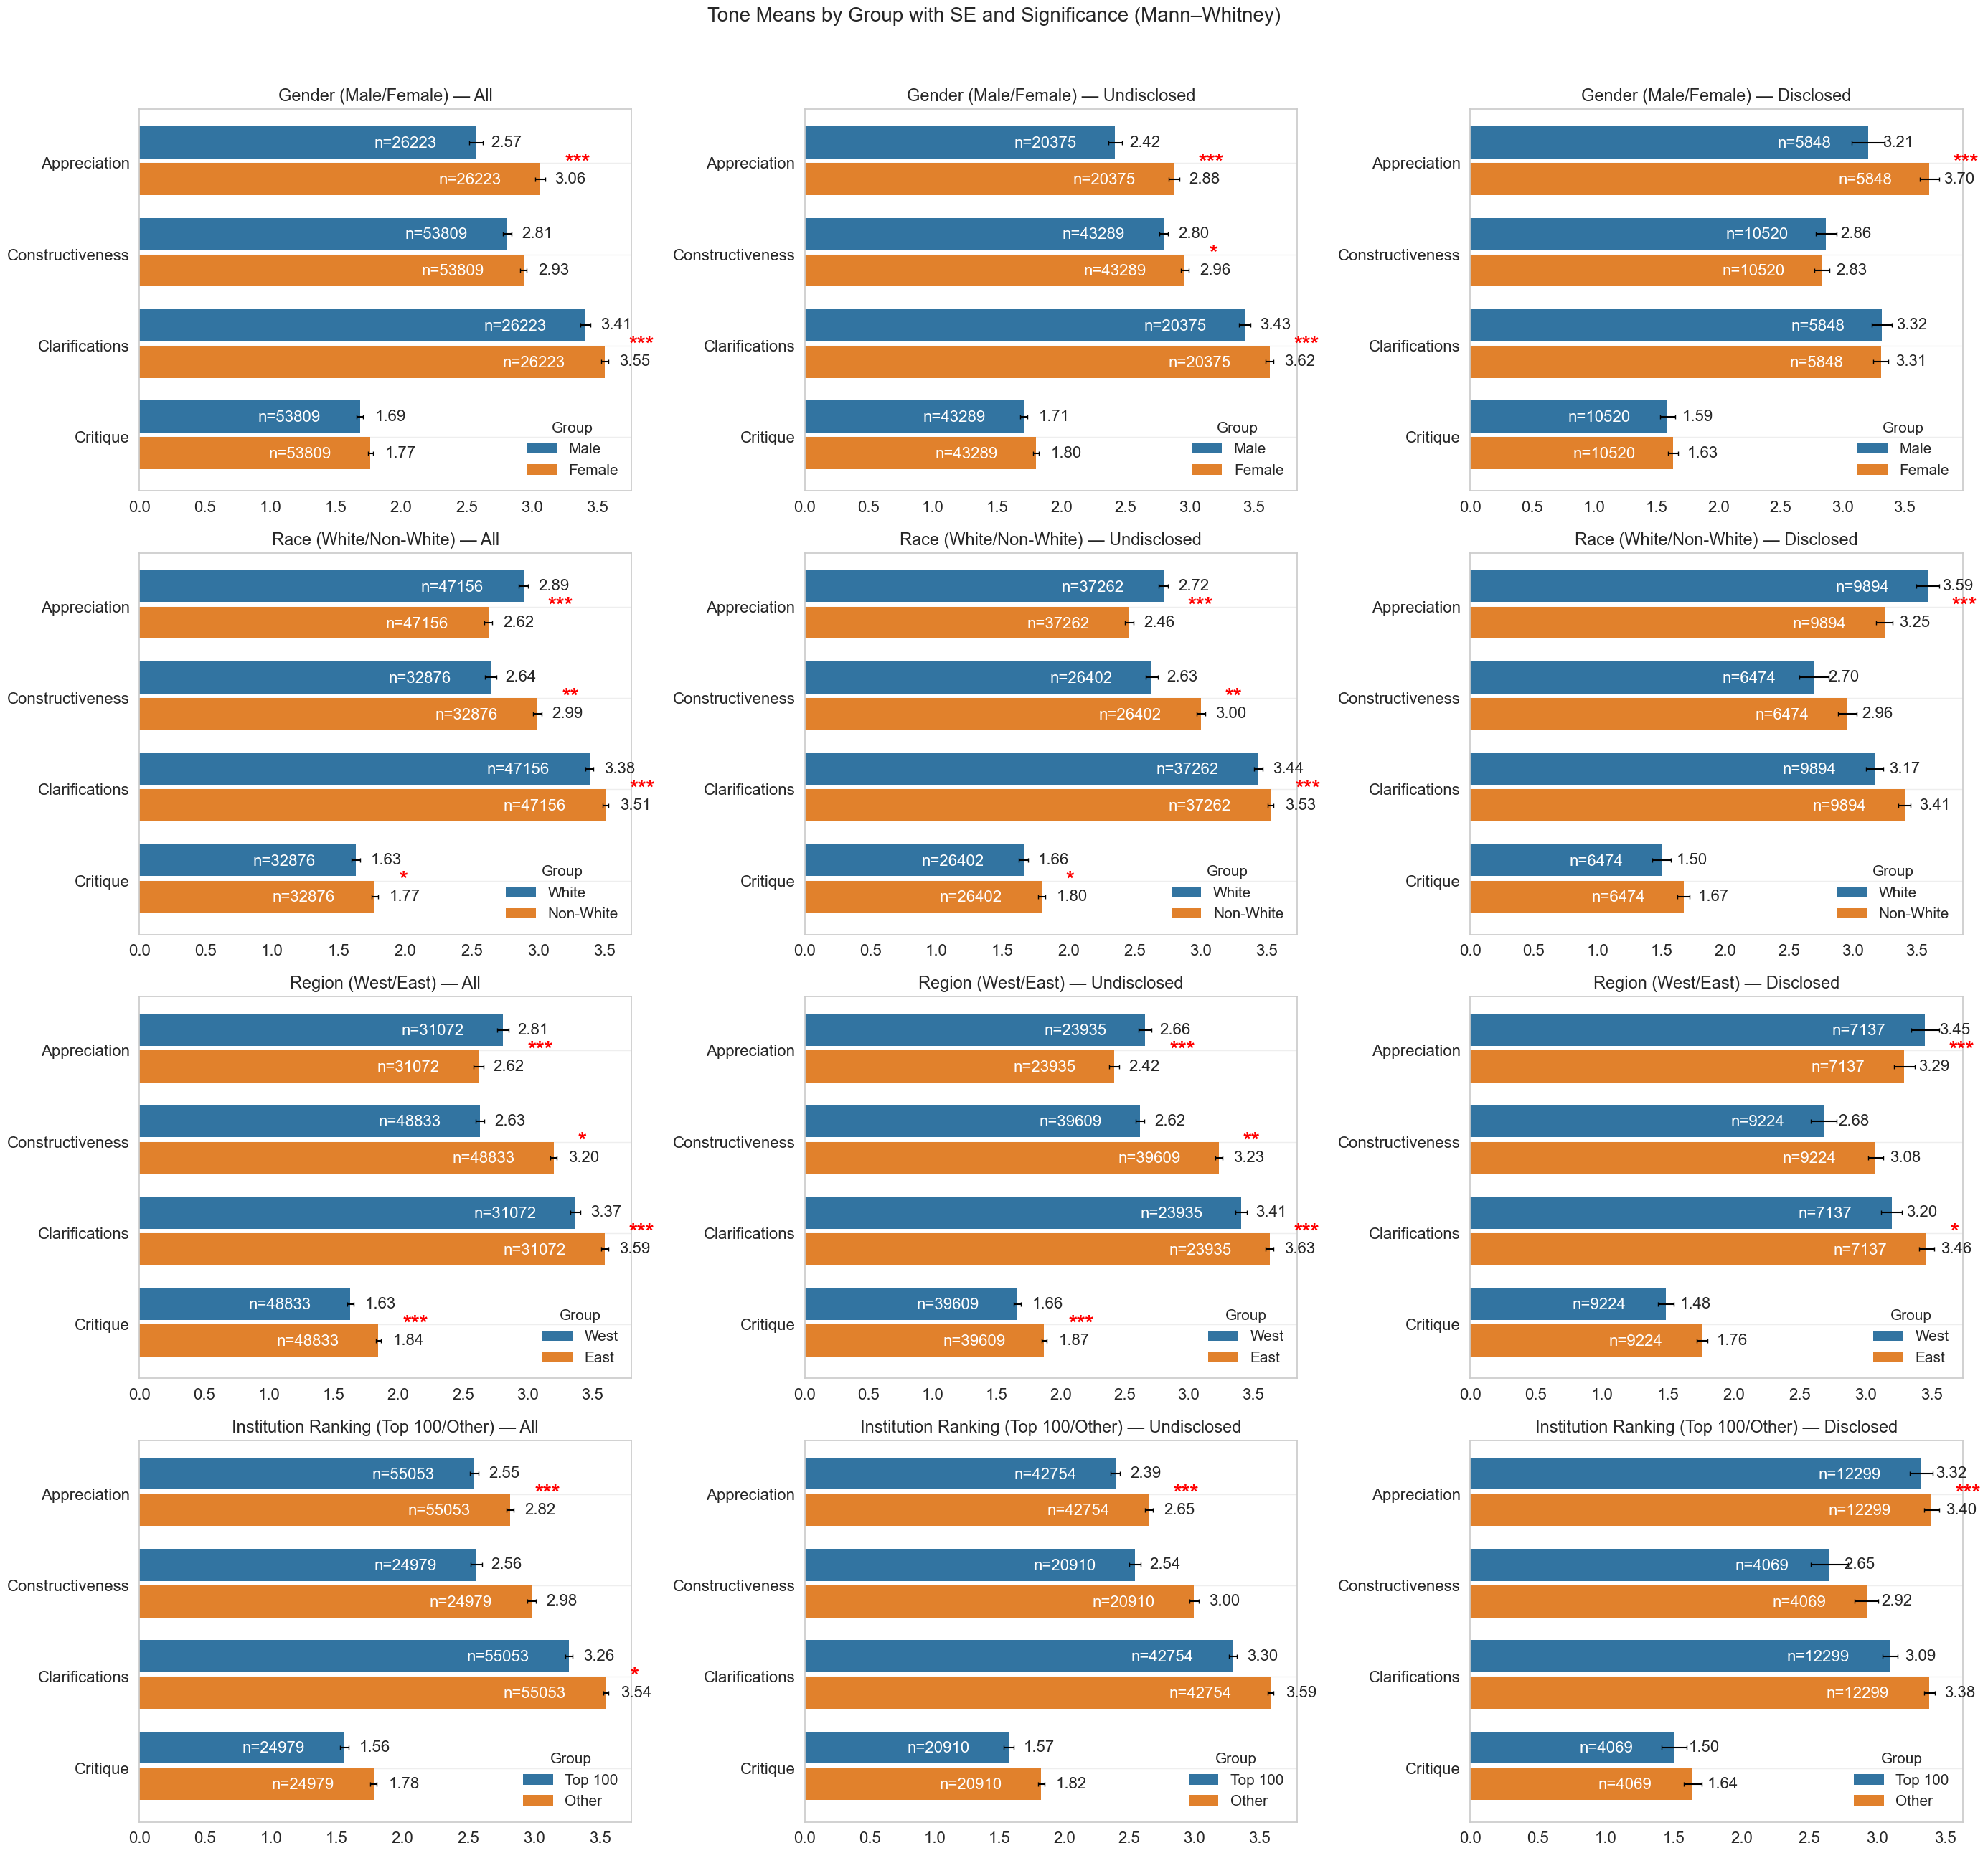

In [74]:
# ------------------------------
# CONFIG
# ------------------------------

TONE_ORDER = ['Appreciation', 'Constructiveness', 'Clarifications', 'Critique']
IDENTITY_ORDER = [ 'All', 'Undisclosed', 'Disclosed'] # column order
CONFOUNDERS_ORDER = ['gender', 'race', 'region', 'uni_rank']  # row order
CONF_LABELS = {
    'gender': {
        'title': 'Gender (Male/Female)',
        'groups': {'Male': 'Male', 'Female': 'Female'}
    },
    'race': {
        'title': 'Race (White/Non-White)',
        'groups': {'White': 'White', 'NonWhite': 'Non-White'}
    },
    'region': {
        'title': 'Region (West/East)',
        'groups': {'Western': 'West', 'Eastern': 'East'}
    },
    'uni_rank': {
        'title': 'Institution Ranking (Top 100/Other)',
        'groups': {'Top100': 'Top 100', 'Other': 'Other'}
    },
}
# palette for group labels 
CUSTOM_PALETTE = {
    'Male': '#1f77b4', 'Female': '#ff7f0e',
    'White': '#1f77b4', 'NonWhite': '#ff7f0e',
    'Western': '#1f77b4', 'Eastern': '#ff7f0e',
    'Top100': '#1f77b4', 'Other': '#ff7f0e'
}
FALLBACK_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

FIGSIZE = (28, 26)
FONT_SIZE = 16
ANNOT_SIZE = 16
MEAN_LABEL_SIZE = 16
STAR_SIZE = 22

SAVE_FIG = False   # set True to save
OUT_PATH = Path("figures/mannwhitney_12subplots.svg")

# ------------------------------
# HELPERS
# ------------------------------
def annotate_significance(p):
    if pd.isna(p):  return ""
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return ""

def color_for(group):
    if group in CUSTOM_PALETTE:
        return CUSTOM_PALETTE[group]
    i = hash(group) % len(FALLBACK_COLORS)
    return FALLBACK_COLORS[i]

def build_plot_df(results_df, confounder, identity):
    """Return df with one row per bar to plot for a specific confounder+identity."""
    sub = results_df[
        (results_df['Confounder'] == confounder) &
        (results_df['Reviewer Identity'] == identity)
    ].copy()
    display_map = CONF_LABELS.get(confounder, {}).get('groups', {})
    # Each row in sub is one comparison (Group1 vs Group2) for a tone
    rows = []
    for _, r in sub.iterrows():
        rows.append({
            "Tone Category": r["Tone Category"],
            "Group": r["Group 1"],
            "GroupDisp": display_map.get(r["Group 1"], r["Group 1"]),
            "Mean": r["Group 1 Mean"],
            "SE": r.get("Group 1 SE", np.nan),
            "N": r.get("Group 1 Size", np.nan),
            "P-value": r["P-value"],
            "Significance": r["Significance"]
        })
        rows.append({
            "Tone Category": r["Tone Category"],
            "Group": r["Group 2"],
            "GroupDisp": display_map.get(r["Group 2"], r["Group 2"]),
            "Mean": r["Group 2 Mean"],
            "SE": r.get("Group 2 SE", np.nan),
            "N": r.get("Group 2 Size", np.nan),
            "P-value": r["P-value"],
            "Significance": r["Significance"]
        })
    out = pd.DataFrame(rows)

    # stable tone ordering and dropping tones missing entirely
    out = out[out['Tone Category'].isin(TONE_ORDER)]
    out['Tone Category'] = pd.Categorical(out['Tone Category'], categories=TONE_ORDER, ordered=True)
    
    return out.sort_values(['Tone Category', 'GroupDisp'])
def draw_subplot(ax, plot_df, subset_for_sig, confounder, identity):
    # color consistency from raw groups, show display labels in legend.
    map_groups = CONF_LABELS.get(confounder, {}).get('groups', {})

    # keeping the raw order (Group 1 then Group 2) and deriving display order from it
    groups_in_order_raw = []
    for _, r in subset_for_sig.iterrows():
        for g in (r['Group 1'], r['Group 2']):
            if g not in groups_in_order_raw:
                groups_in_order_raw.append(g)

    groups_in_order_disp = [map_groups.get(g, g) for g in groups_in_order_raw]
    palette = {map_groups.get(g, g): color_for(g) for g in groups_in_order_raw}

    sns.barplot(
        data=plot_df, y="Tone Category", x="Mean", hue="GroupDisp",
        order=TONE_ORDER, hue_order=groups_in_order_disp,
        palette=palette, dodge=True, ax=ax, edgecolor='none'
    )

    # Slim bars
    for c in ax.containers:
        for bar in c:
            bar.set_height(0.35)

    # annotations: error bars + mean labels + N labels
    bars = [b for c in ax.containers for b in c]
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0] if ax.get_xlim()[1] != ax.get_xlim()[0] else 1.0
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height()/2

        if pd.notna(row["SE"]) and row["SE"] > 0:
            ax.errorbar(x=x, y=y, xerr=row["SE"], fmt='none', ecolor='black', elinewidth=1.5, capsize=2.5)

        # Mean-Whitney value 
        ax.text(x + 0.03 * x_range, y, f"{x:.2f}", va='center', ha='left', fontsize=MEAN_LABEL_SIZE)

        # N label 
        if pd.notna(row.get("N", np.nan)):
            ax.text(
                x - 0.3,  # shift left
                y - bar.get_height()/4 + 0.02,
                f"n={int(row['N'])}",
                va='top',
                ha='right',
                fontsize=ANNOT_SIZE,
                color="#FFFFFF"
            )

    # Significance stars
    y_positions = {tone: i for i, tone in enumerate(TONE_ORDER)}
    for tone in TONE_ORDER:
        pair = subset_for_sig[subset_for_sig["Tone Category"] == tone]
        if pair.empty:
            continue
        m1 = pair.iloc[0]["Group 1 Mean"]; m2 = pair.iloc[0]["Group 2 Mean"]
        p  = pair.iloc[0]["P-value"]
        star = annotate_significance(p)
        if star:
            xmax = np.nanmax([m1, m2])
            ax.text(xmax + 0.05 * x_range, y_positions[tone],
                    star, ha='left', va='center', fontsize=STAR_SIZE, fontweight='bold', color='#FF0000')

    # Title
    title_txt = CONF_LABELS.get(confounder, {}).get('title', confounder)
    ax.set_title(f"{title_txt} — {identity}", fontsize=FONT_SIZE+1, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis='y', color='#eee')
    ax.grid(False, axis='x')
    ax.tick_params(axis='both', labelsize=FONT_SIZE)
    ax.legend(title="Group", loc='lower right', fontsize=FONT_SIZE-1,
              title_fontsize=FONT_SIZE-1, frameon=False)


def plot_results_grid(results_df):
    required_cols = {
        'Tone Category','Reviewer Identity','Confounder',
        'Group 1','Group 2',
        'Group 1 Mean','Group 1 SE','Group 1 Size',
        'Group 2 Mean','Group 2 SE','Group 2 Size',
        'P-value'
    }
    missing = required_cols - set(results_df.columns)
    if missing:
        raise ValueError(f"results_df is missing columns: {missing}")

    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': FONT_SIZE})

    fig, axes = plt.subplots(len(CONFOUNDERS_ORDER), len(IDENTITY_ORDER),
                             figsize=FIGSIZE, sharex=False)
    axes = np.atleast_2d(axes)

    fig.suptitle("Tone Means by Group with SE and Significance (Mann–Whitney)",
                 fontsize=FONT_SIZE+4, y=0.995)

    for i, confounder in enumerate(CONFOUNDERS_ORDER):
        for j, identity in enumerate(IDENTITY_ORDER):
            ax = axes[i, j]
            subset_for_sig = results_df[
                (results_df['Confounder'] == confounder) &
                (results_df['Reviewer Identity'] == identity)
            ].copy()

            if subset_for_sig.empty:
                ax.axis('off')
                ax.set_title(f"{confounder} ({identity}) — no data", fontsize=FONT_SIZE)
                continue

            plot_df = build_plot_df(results_df, confounder, identity)
            draw_subplot(ax, plot_df, subset_for_sig, confounder, identity)

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if SAVE_FIG:
        OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
        print(f"Saved figure → {OUT_PATH.resolve()}")

    plt.show()

# ------------------------------
# USAGE
# ------------------------------

plot_results_grid(results_ttest)
